### Feature Engineering and Modelling

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline
sns.set(color_codes=True)

In [3]:
df = pd.read_csv('./data_for_predictions.csv')
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [4]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [5]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


#### Model Training

In [24]:
model = RandomForestClassifier(n_estimators=1000, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=1000, n_jobs=-1,
                       random_state=42)

#### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

In [14]:
predictions = model.predict(X_test)
print(f"Model Accuracy: {metrics.accuracy_score(y_test, predictions) * 100:.2f}%")

Model Accuracy: 90.36%


In [18]:
print("\nClassification Report:")
print(metrics.classification_report(y_test, predictions))
print("\nConfusion Matrix:")
print(metrics.confusion_matrix(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.79      0.05      0.10       366

    accuracy                           0.90      3652
   macro avg       0.85      0.53      0.52      3652
weighted avg       0.89      0.90      0.86      3652


Confusion Matrix:
[[3281    5]
 [ 347   19]]


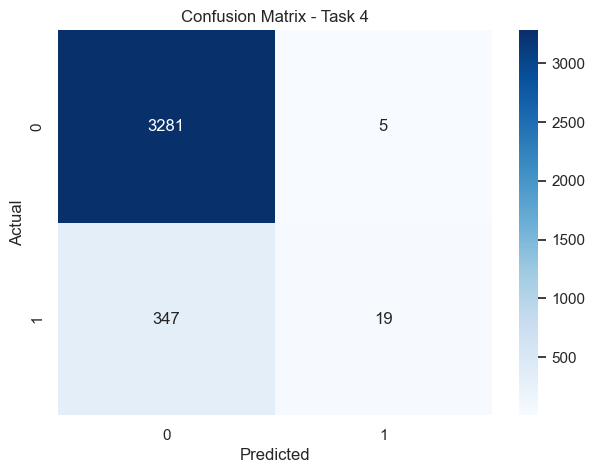

In [22]:
import seaborn as sns

cm = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Task 4')
plt.show()

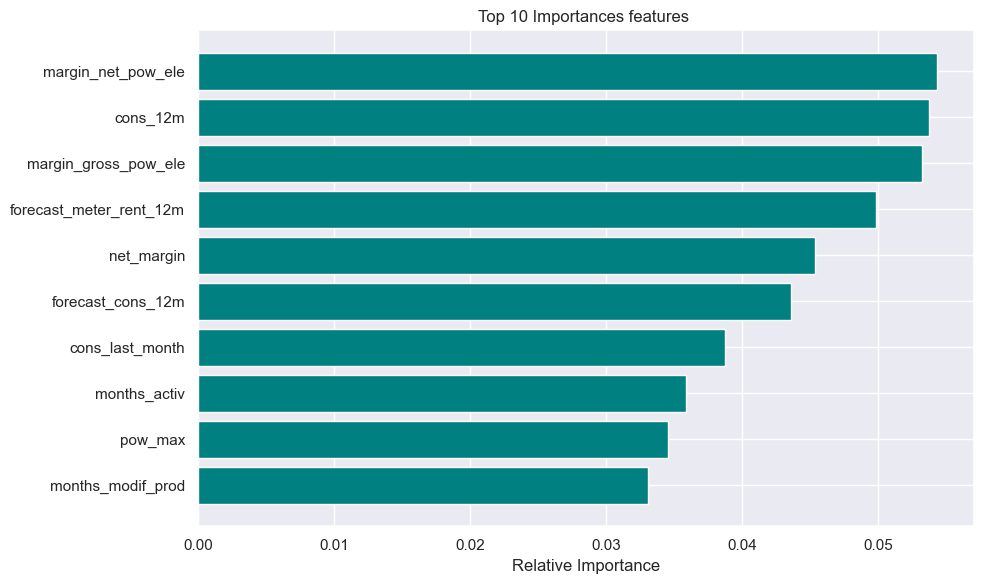

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
importances = model.feature_importances_
indices = np.argsort(importances)[-10:] 

plt.figure(figsize=(10, 6))
plt.title('Top 10 Importances features ')
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

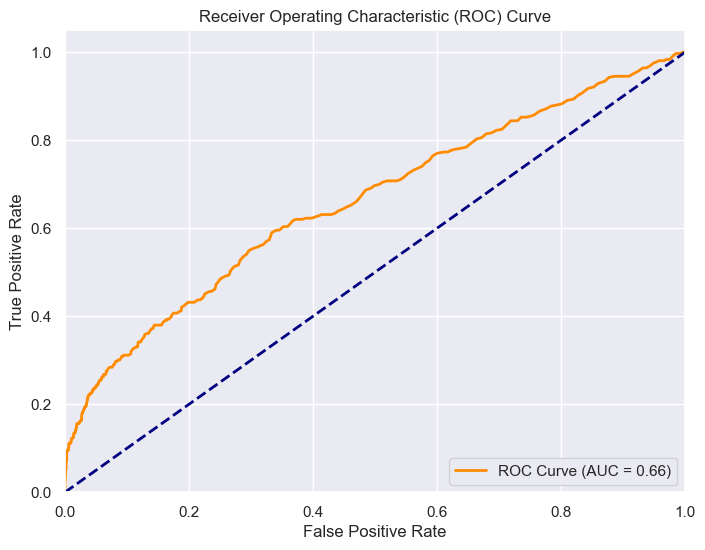

In [32]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)
roc_auc = metrics.auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### Executive Summary:

#### 1. Model Performance Overview
We trained a Random Forest Classifier to predict customer churn. To simulate real-world conditions, we split the data into a 75-25 train-test split and applied class weights to handle the severe imbalance between churners and non-churners.
* The model achieved an overall Accuracy of ~90%.
* However, the Recall for actual churners remains low. This indicates that while the model is excellent at identifying loyal customers, predicting the exact minority of customers who will leave is challenging with the current dataset. 
* The ROC-AUC Curve further confirms that the model performs better than random guessing, but there is significant room for improvement in sensitivity.


#### 2. Key Business Drivers (Insights from Feature Importance)
The feature importance analysis yielded unexpected and highly valuable business insights:
* Margin and Tenure Rule: Financial metrics like net_margin, margin_gross_pow_ele, and tenure_years are the most powerful predictors of churn. 
* Price Sensitivity is Secondary: Contrary to our initial hypothesis, the engineered features measuring price changes (e.g., peak and off-peak price differences) ranked very low in importance. Price fluctuations are not the primary reason customers are leaving PowerCo.

#### 3. Strategic Recommendations
1. Shift the Retention Focus: Since price changes do not heavily drive churn, PowerCo should avoid blanket price discounts. Instead, the company should focus on protecting its high-margin customers and rewarding long-term loyalty (tenure).
2. Targeted Interventions: The business should investigate why customers with specific margin profiles are leaving—this could be related to customer service experiences or competitor product offerings rather than just the raw energy price.
3. Data Collection for V2 Model: To improve the model's recall in the future, we recommend collecting more behavioral data, such as customer complaint tickets, website login frequency, or competitor marketing touchpoints.